# Загрузка библиотек

In [1]:
!pip install pandas
!pip install seaborn
!pip install matplotlib
!pip install phik
!pip install scikit-learn
!pip install lightgbm


[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: C:\test_sibintec\myvenv\Scripts\python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: C:\test_sibintec\myvenv\Scripts\python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: C:\test_sibintec\myvenv\Scripts\python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: C:\test_sibintec\myvenv\Scripts\python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: C:\test_sibintec\myvenv\Scripts\python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: C:\test_sibintec\myvenv\Scripts\python.exe -m pip install --upgrade pip


In [35]:
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import phik
from phik import resources

from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    precision_recall_curve,
)

import lightgbm as lgb

In [3]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# EDA

In [4]:
df = pd.read_csv('data/SWaT_Dataset_Attack_v0.csv', sep=';')

C:\Users\serge\AppData\Local\Temp\ipykernel_15508\2756131780.py:1: DtypeWarning: Columns (0: FIT101, 1: FIT201, 2: FIT401, 3: PIT502) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/SWaT_Dataset_Attack_v0.csv', sep=';')


In [5]:
df.head()

,Timestamp,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,MV201,P201,P202,P203,P204,P205,P206,DPIT301,FIT301,LIT301,MV301,MV302,MV303,MV304,P301,P302,AIT401,AIT402,FIT401,LIT401,P401,P402,P403,P404,UV401,AIT501,AIT502,AIT503,AIT504,FIT501,FIT502,FIT503,FIT504,P501,P502,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,Normal/Attack
0,28/12/2015 10:00:00 AM,"2,427057","522,8467",2,2,1,"262,0161","8,396437","328,6337","2,445391",2,1,1,2,1,2,1,"19,74838","2,206835","956,1651",1,2,1,1,1,2,"148,808","156,0882","1,713517","942,0662",1,2,1,1,2,"7,878621","145,1166","264,5475","12,03538","1,723789","1,279621","0,7352687","0,3077859",2,1,"250,8652","1,649953","189,5988","0,000128152",1,1,1,Normal
1,28/12/2015 10:00:01 AM,"2,446274","522,886",2,2,1,"262,0161","8,396437","328,6337","2,445391",2,1,1,2,1,2,1,"19,74838","2,208244","956,1651",1,2,1,1,1,2,"148,808","156,0882","1,715952","942,0277",1,2,1,1,2,"7,878621","145,1166","264,5475","12,03538","1,723789","1,297554","0,7352687","0,3077859",2,1,"250,8652","1,649953","189,6789","0,000128152",1,1,1,Normal
2,28/12/2015 10:00:02 AM,"2,489191","522,8467",2,2,1,"262,0161","8,394514","328,6337","2,442316",2,1,1,2,1,2,1,"19,69076","2,208628","956,4855",1,2,1,1,1,2,"148,808","156,0882","1,715952","941,8739",1,2,1,1,2,"7,878621","145,1166","264,5475","12,03538","1,723404","1,293967","0,7352687","0,3086186",2,1,"250,8812","1,649953","189,6789","0,000128152",1,1,1,Normal
3,28/12/2015 10:00:03 AM,"2,53435","522,9645",2,2,1,"262,0161","8,394514","328,6337","2,442316",2,1,1,2,1,2,1,"19,69076","2,208628","956,806",1,2,1,1,1,2,"148,808","156,0882","1,71467","941,797",1,2,1,1,2,"7,878621","145,0141","264,5475","12,03538","1,723404","1,281158","0,7352687","0,3086186",2,1,"250,8812","1,649953","189,6148","0,000128152",1,1,1,Normal
4,28/12/2015 10:00:04 AM,"2,56926","523,4748",2,2,1,"262,0161","8,394514","328,6337","2,443085",2,1,1,2,1,2,1,"19,69076","2,208628","957,0864",1,2,1,1,1,2,"148,808","156,0882","1,71467","942,22",1,2,1,1,2,"7,878621","144,8859","264,5475","12,03538","1,723404","1,281158","0,7352687","0,3086186",2,1,"250,8812","1,649953","189,5027","0,000128152",1,1,1,Normal


In [6]:
df.value_counts().sum()

np.int64(449919)

In [7]:
df["Normal/Attack"].value_counts()

Normal/Attack
Normal     395298
Attack      54584
A ttack        37
Name: count, dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

## Преобразование данных

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 449919 entries, 0 to 449918
Data columns (total 53 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Timestamp      449919 non-null  str   
 1   FIT101         449919 non-null  object
 2   LIT101         449919 non-null  str   
 3   MV101          449919 non-null  int64 
 4   P101           449919 non-null  int64 
 5   P102           449919 non-null  int64 
 6   AIT201         449919 non-null  str   
 7   AIT202         449919 non-null  str   
 8   AIT203         449919 non-null  str   
 9   FIT201         449919 non-null  object
 10  MV201          449919 non-null  int64 
 11  P201           449919 non-null  int64 
 12  P202           449919 non-null  int64 
 13  P203           449919 non-null  int64 
 14  P204           449919 non-null  int64 
 15  P205           449919 non-null  int64 
 16  P206           449919 non-null  int64 
 17  DPIT301        449919 non-null  str   
 18  FIT301         

In [10]:
cols_to_convert = [col for col in df.columns 
                   if df[col].dtype == 'object' or df[col].dtype == 'str'
                   and col not in ['Timestamp', 'Normal/Attack']]

for col in cols_to_convert:
    df[col] = df[col].str.replace(',', '.').astype(float)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 449919 entries, 0 to 449918
Data columns (total 53 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Timestamp      449919 non-null  str    
 1   FIT101         433535 non-null  float64
 2   LIT101         449919 non-null  float64
 3   MV101          449919 non-null  int64  
 4   P101           449919 non-null  int64  
 5   P102           449919 non-null  int64  
 6   AIT201         449919 non-null  float64
 7   AIT202         449919 non-null  float64
 8   AIT203         449919 non-null  float64
 9   FIT201         433535 non-null  float64
 10  MV201          449919 non-null  int64  
 11  P201           449919 non-null  int64  
 12  P202           449919 non-null  int64  
 13  P203           449919 non-null  int64  
 14  P204           449919 non-null  int64  
 15  P205           449919 non-null  int64  
 16  P206           449919 non-null  int64  
 17  DPIT301        449919 non-null  float64


In [12]:
df['Normal/Attack'].value_counts()

Normal/Attack
Normal     395298
Attack      54584
A ttack        37
Name: count, dtype: int64

1 - 'Attack' <br>
0 - 'Normal'

In [13]:
df['Normal/Attack'] = df['Normal/Attack'].replace('A ttack', 'Attack')
df['target'] = (df['Normal/Attack'] == 'Attack').astype(int)
df.drop('Normal/Attack', axis=1, inplace=True)

In [14]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'].str.strip(), format='%d/%m/%Y %I:%M:%S %p')

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.isna().sum()

Timestamp        0
FIT101       16384
LIT101           0
MV101            0
P101             0
P102             0
AIT201           0
AIT202           0
AIT203           0
FIT201       16384
MV201            0
P201             0
P202             0
P203             0
P204             0
P205             0
P206             0
DPIT301          0
FIT301           0
LIT301           0
MV301            0
MV302            0
MV303            0
MV304            0
P301             0
P302             0
AIT401           0
AIT402           0
FIT401       16384
LIT401           0
P401             0
P402             0
P403             0
P404             0
UV401            0
AIT501           0
AIT502           0
AIT503           0
AIT504           0
FIT501           0
FIT502           0
FIT503           0
FIT504           0
P501             0
P502             0
PIT501           0
PIT502       16384
PIT503           0
FIT601           0
P601             0
P602             0
P603             0
target      

**Гипотезы по пропускам:**

- Возможно пропуски и связаны с атаками и являются важным признаком
- Возможно пропуски связаны с отказом оборудования (FIT - показывает расход воды, PIT - давление в трубопроводах). Почему именно в этих..?
- Возможно из стоит заплонить ближайшеми значениями, так как измерения производятся каждую секунду

In [17]:
print('FIT101 NaN & target=0:', df[(df['FIT101'].isna()) & (df['target'] == 0)].shape[0])
print('FIT201 NaN & target=0:', df[(df['FIT201'].isna()) & (df['target'] == 0)].shape[0])
print('FIT401 NaN & target=0:', df[(df['FIT401'].isna()) & (df['target'] == 0)].shape[0])
print('PIT502 NaN & target=0:', df[(df['PIT502'].isna()) & (df['target'] == 0)].shape[0])
print('Совпадение пропусков:',  df[(df['FIT101'].isna()) & (df['FIT201'].isna()) & (df['FIT401'].isna()) & (df['PIT502'].isna())].shape[0])

FIT101 NaN & target=0: 0
FIT201 NaN & target=0: 0
FIT401 NaN & target=0: 0
PIT502 NaN & target=0: 0
Совпадение пропусков: 16384


In [18]:
df[df['FIT101'].isna()].head()

,Timestamp,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,MV201,P201,P202,P203,P204,P205,P206,DPIT301,FIT301,LIT301,MV301,MV302,MV303,MV304,P301,P302,AIT401,AIT402,FIT401,LIT401,P401,P402,P403,P404,UV401,AIT501,AIT502,AIT503,AIT504,FIT501,FIT502,FIT503,FIT504,P501,P502,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,target
245760,2015-12-31 06:16:00,NaN,814.3770,1,1,1,192.8672,8.589977,350.2179,NaN,1,1,1,1,1,1,1,2.003969,0.0,1015.685,1,1,1,2,1,1,148.808,330.8126,NaN,248.1671,1,1,1,1,1,7.535440,234.2733,267.7839,15.53448,0.000897,0.001153,0.000896,0.0,1,1,10.06152,NaN,3.733017,0.0,1,1,1,1
245761,2015-12-31 06:16:01,NaN,814.2985,1,1,1,192.8672,8.589977,350.2179,NaN,1,1,1,1,1,1,1,2.003969,0.0,1015.485,1,1,1,2,1,1,148.808,330.8126,NaN,248.2440,1,1,1,1,1,7.535440,234.2733,267.7839,15.53448,0.000897,0.001153,0.000896,0.0,1,1,10.06152,NaN,3.733017,0.0,1,1,1,1
245762,2015-12-31 06:16:02,NaN,813.8275,1,1,1,192.8672,8.589977,350.2179,NaN,1,1,1,1,1,1,1,2.003969,0.0,1015.685,1,1,1,2,1,1,148.808,330.8126,NaN,248.3209,1,1,1,1,1,7.535440,234.2733,267.7839,15.53448,0.000897,0.001153,0.000896,0.0,1,1,10.06152,NaN,3.733017,0.0,1,1,1,1
245763,2015-12-31 06:16:03,NaN,813.9059,1,1,1,192.8672,8.589977,350.2179,NaN,1,1,1,1,1,1,1,2.003969,0.0,1015.685,1,1,1,2,1,1,148.808,330.8126,NaN,248.3594,1,1,1,1,1,7.536401,234.2733,267.7839,15.53448,0.000897,0.001153,0.000896,0.0,1,1,10.06152,NaN,3.733017,0.0,1,1,1,1
245764,2015-12-31 06:16:04,NaN,814.0237,1,1,1,192.8672,8.589977,350.2179,NaN,1,1,1,1,1,1,1,2.003969,0.0,1015.445,1,1,1,2,1,1,148.808,330.8126,NaN,247.9749,1,1,1,1,1,7.537042,234.2733,267.7839,15.53448,0.000897,0.001153,0.000896,0.0,1,1,10.06152,NaN,3.733017,0.0,1,1,1,1


In [19]:
df[df['FIT101'].isna()].tail()

,Timestamp,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,MV201,P201,P202,P203,P204,P205,P206,DPIT301,FIT301,LIT301,MV301,MV302,MV303,MV304,P301,P302,AIT401,AIT402,FIT401,LIT401,P401,P402,P403,P404,UV401,AIT501,AIT502,AIT503,AIT504,FIT501,FIT502,FIT503,FIT504,P501,P502,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,target
262139,2015-12-31 10:48:59,NaN,812.6498,1,1,1,197.4494,8.524609,369.4694,NaN,1,1,1,1,1,1,1,2.035982,0.0,1016.566,1,1,1,2,1,1,148.808,326.3778,NaN,247.4750,1,1,1,1,1,7.440592,187.4648,269.9308,15.61138,0.001025,0.001153,0.001152,0.0,1,1,9.628942,NaN,3.316457,0.0,1,1,1,1
262140,2015-12-31 10:49:00,NaN,813.0031,1,1,1,197.4494,8.524609,369.4694,NaN,1,1,1,1,1,1,1,2.035982,0.0,1016.727,1,1,1,2,1,1,148.808,326.3778,NaN,247.0905,1,1,1,1,1,7.440592,187.4648,269.9308,15.61138,0.001025,0.001153,0.001152,0.0,1,1,9.628942,NaN,3.316457,0.0,1,1,1,1
262141,2015-12-31 10:49:01,NaN,812.9639,1,1,1,197.4494,8.524609,369.4694,NaN,1,1,1,1,1,1,1,2.035982,0.0,1016.767,1,1,1,2,1,1,148.808,326.3778,NaN,246.9367,1,1,1,1,1,7.440592,187.4648,269.9308,15.61138,0.001025,0.001153,0.001152,0.0,1,1,9.628942,NaN,3.316457,0.0,1,1,1,1
262142,2015-12-31 10:49:02,NaN,812.9639,1,1,1,197.4494,8.524609,369.4694,NaN,1,1,1,1,1,1,1,2.035982,0.0,1016.486,1,1,1,2,1,1,148.808,326.3778,NaN,246.9367,1,1,1,1,1,7.440592,187.4648,269.9308,15.61138,0.001025,0.001153,0.001152,0.0,1,1,9.628942,NaN,3.316457,0.0,1,1,1,1
262143,2015-12-31 10:49:03,NaN,813.2386,1,1,1,197.4494,8.524609,369.4694,NaN,1,1,1,1,1,1,1,2.035982,0.0,1016.767,1,1,1,2,1,1,148.808,326.3778,NaN,246.8982,1,1,1,1,1,7.440592,187.4648,269.9308,15.61138,0.001025,0.001153,0.001152,0.0,1,1,9.628942,NaN,3.316457,0.0,1,1,1,1


Пока что для базового решения примим теорию о том, что пропуски являются признаком атаки и важной информацией для модели. В случае реальной работы врядли такое решение подойдет (там стоит поглубже разобраться откуда пропуски, поискать больше законмерностей, сходить к инженерам/механникам и т.д.), но для тестового задания это может сильно улучшить качество модели. Плюс в пользу версии отказа оборудования гововрит, что все пропуски были в 1 день.

Заменю пропуск -1, потому что такое значение никогда не встречается.

In [20]:
df.describe()

,Timestamp,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,MV201,P201,P202,P203,P204,P205,P206,DPIT301,FIT301,LIT301,MV301,MV302,MV303,MV304,P301,P302,AIT401,AIT402,FIT401,LIT401,P401,P402,P403,P404,UV401,AIT501,AIT502,AIT503,AIT504,FIT501,FIT502,FIT503,FIT504,P501,P502,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,target
count,449919,433535.000000,449919.000000,449919.000000,449919.000000,449919.000000,449919.000000,449919.000000,449919.000000,433535.000000,449919.000000,449919.000000,449919.0,449919.000000,449919.000000,449919.000000,449919.000000,449919.000000,449919.000000,449919.000000,449919.000000,449919.000000,449919.000000,449919.000000,449919.0,449919.000000,449919.000000,449919.000000,433535.000000,449919.000000,449919.0,449919.000000,449919.000000,449919.0,449919.000000,449919.000000,449919.000000,449919.000000,449919.000000,449919.000000,449919.000000,449919.000000,449919.000000,449919.000000,449919.0,449919.000000,433535.000000,449919.000000,449919.000000,449919.0,449919.000000,449919.0,449919.000000
mean,2015-12-31 00:29:46.199656,1.779134,607.019967,1.665335,1.693251,1.006946,210.297302,8.528535,320.301478,1.767263,1.691584,1.121068,1.0,1.690689,1.000124,1.691131,1.000122,15.827634,1.713555,910.076801,1.007321,1.749655,1.023349,1.101163,1.0,1.772946,148.805855,161.990135,1.650311,833.542913,1.0,1.928792,1.000133,1.0,1.925849,7.787358,147.509939,264.789668,14.504030,1.603014,1.195462,0.679549,0.283806,1.925862,1.0,232.173817,1.051706,174.714484,0.016566,1.0,1.009099,1.0,0.121402
min,2015-12-28 10:00:00,0.000000,189.826300,0.000000,1.000000,1.000000,168.033800,6.000000,285.337100,0.000000,0.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,364.386300,0.000000,0.000000,0.000000,0.000000,1.0,1.000000,148.759900,140.835700,0.000000,243.014600,1.0,1.000000,1.000000,1.0,1.000000,7.432902,129.838500,244.873100,9.536016,0.000000,0.000000,0.000000,0.000000,1.000000,1.0,9.468726,0.000000,3.140220,0.000000,1.0,1.000000,1.0,0.000000
25%,2015-12-29 17:14:39.500000,0.000000,510.011100,1.000000,1.000000,1.000000,177.102000,8.441618,306.383000,0.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,19.316220,2.194664,836.444200,1.000000,2.000000,1.000000,1.000000,1.0,2.000000,148.803200,146.116400,1.710826,819.097700,1.0,2.000000,1.000000,1.0,2.000000,7.772879,138.990000,259.965400,13.035120,1.719559,1.272576,0.730660,0.306249,2.000000,1.0,248.029400,0.816967,186.698900,0.000000,1.0,1.000000,1.0,0.000000
50%,2015-12-31 00:29:19,2.485667,530.422500,2.000000,2.000000,1.000000,193.508100,8.551525,321.661100,2.447570,2.000000,1.000000,1.0,2.000000,1.000000,2.000000,1.000000,19.898840,2.201582,924.682800,1.000000,2.000000,1.000000,1.000000,1.0,2.000000,148.808000,150.166600,1.717874,884.427100,1.0,2.000000,1.000000,1.0,2.000000,7.797873,142.912100,264.387300,14.611640,1.726993,1.286410,0.732708,0.306633,2.000000,1.0,249.295100,0.977157,187.724300,0.000000,1.0,1.000000,1.0,0.000000
75%,2016-01-01 07:45:19.500000,2.582711,727.432100,2.000000,2.000000,1.000000,253.845200,8.610806,331.684200,2.454875,2.000000,1.000000,1.0,2.000000,1.000000,2.000000,1.000000,20.116530,2.207091,977.794200,1.000000,2.000000,1.000000,1.000000,1.0,2.000000,148.808000,153.652900,1.724282,937.375100,1.0,2.000000,1.000000,1.0,2.000000,7.840810,144.706500,269.129700,15.419120,1.733145,1.300115,0.734885,0.308106,2.000000,1.0,250.881200,1.409669,189.118200,0.000128,1.0,1.000000,1.0,0.000000
max,2016-01-02 14:59:59,2.760145,925.032300,2.000000,2.000000,2.000000,267.719800,8.733210,384.465500,2.826899,2.000000,2.000000,1.0,2.000000,2.000000,2.000000,2.000000,45.000000,2.376197,1201.000000,2.000000,2.000000,2.000000,2.000000,1.0,2.000000,148.856100,333.811800,1.744914,1002.781000,1.0,2.000000,2.000000,1.0,2.000000,8.307037,272.853100,297.263500,442.463500,1.753653,1.360318,0.741542,0.311693,2.000000,1.0,254.341800,1.970333,191.986000,1.802710,1.0,2.000000,1.0,1.000000
std,NaN,1.165586,125.303003,0.482323,0.461145,0.083051,35.

In [21]:
cols_with_nan = ['FIT101', 'FIT201', 'FIT401', 'PIT502']
df[cols_with_nan] = df[cols_with_nan].fillna(-1)

In [22]:
df.isna().sum().sum()

np.int64(0)

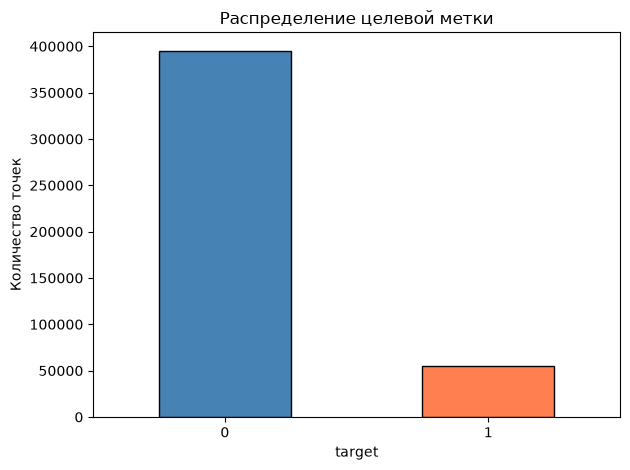

In [23]:
df['target'].value_counts().plot(kind='bar', color=['steelblue', 'coral'], edgecolor='black')
plt.title('Распределение целевой метки')
plt.ylabel('Количество точек')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [24]:
df['target'].value_counts(normalize=True) 

target
0    0.878598
1    0.121402
Name: proportion, dtype: float64

Присутствует дисбаланс, но не большой

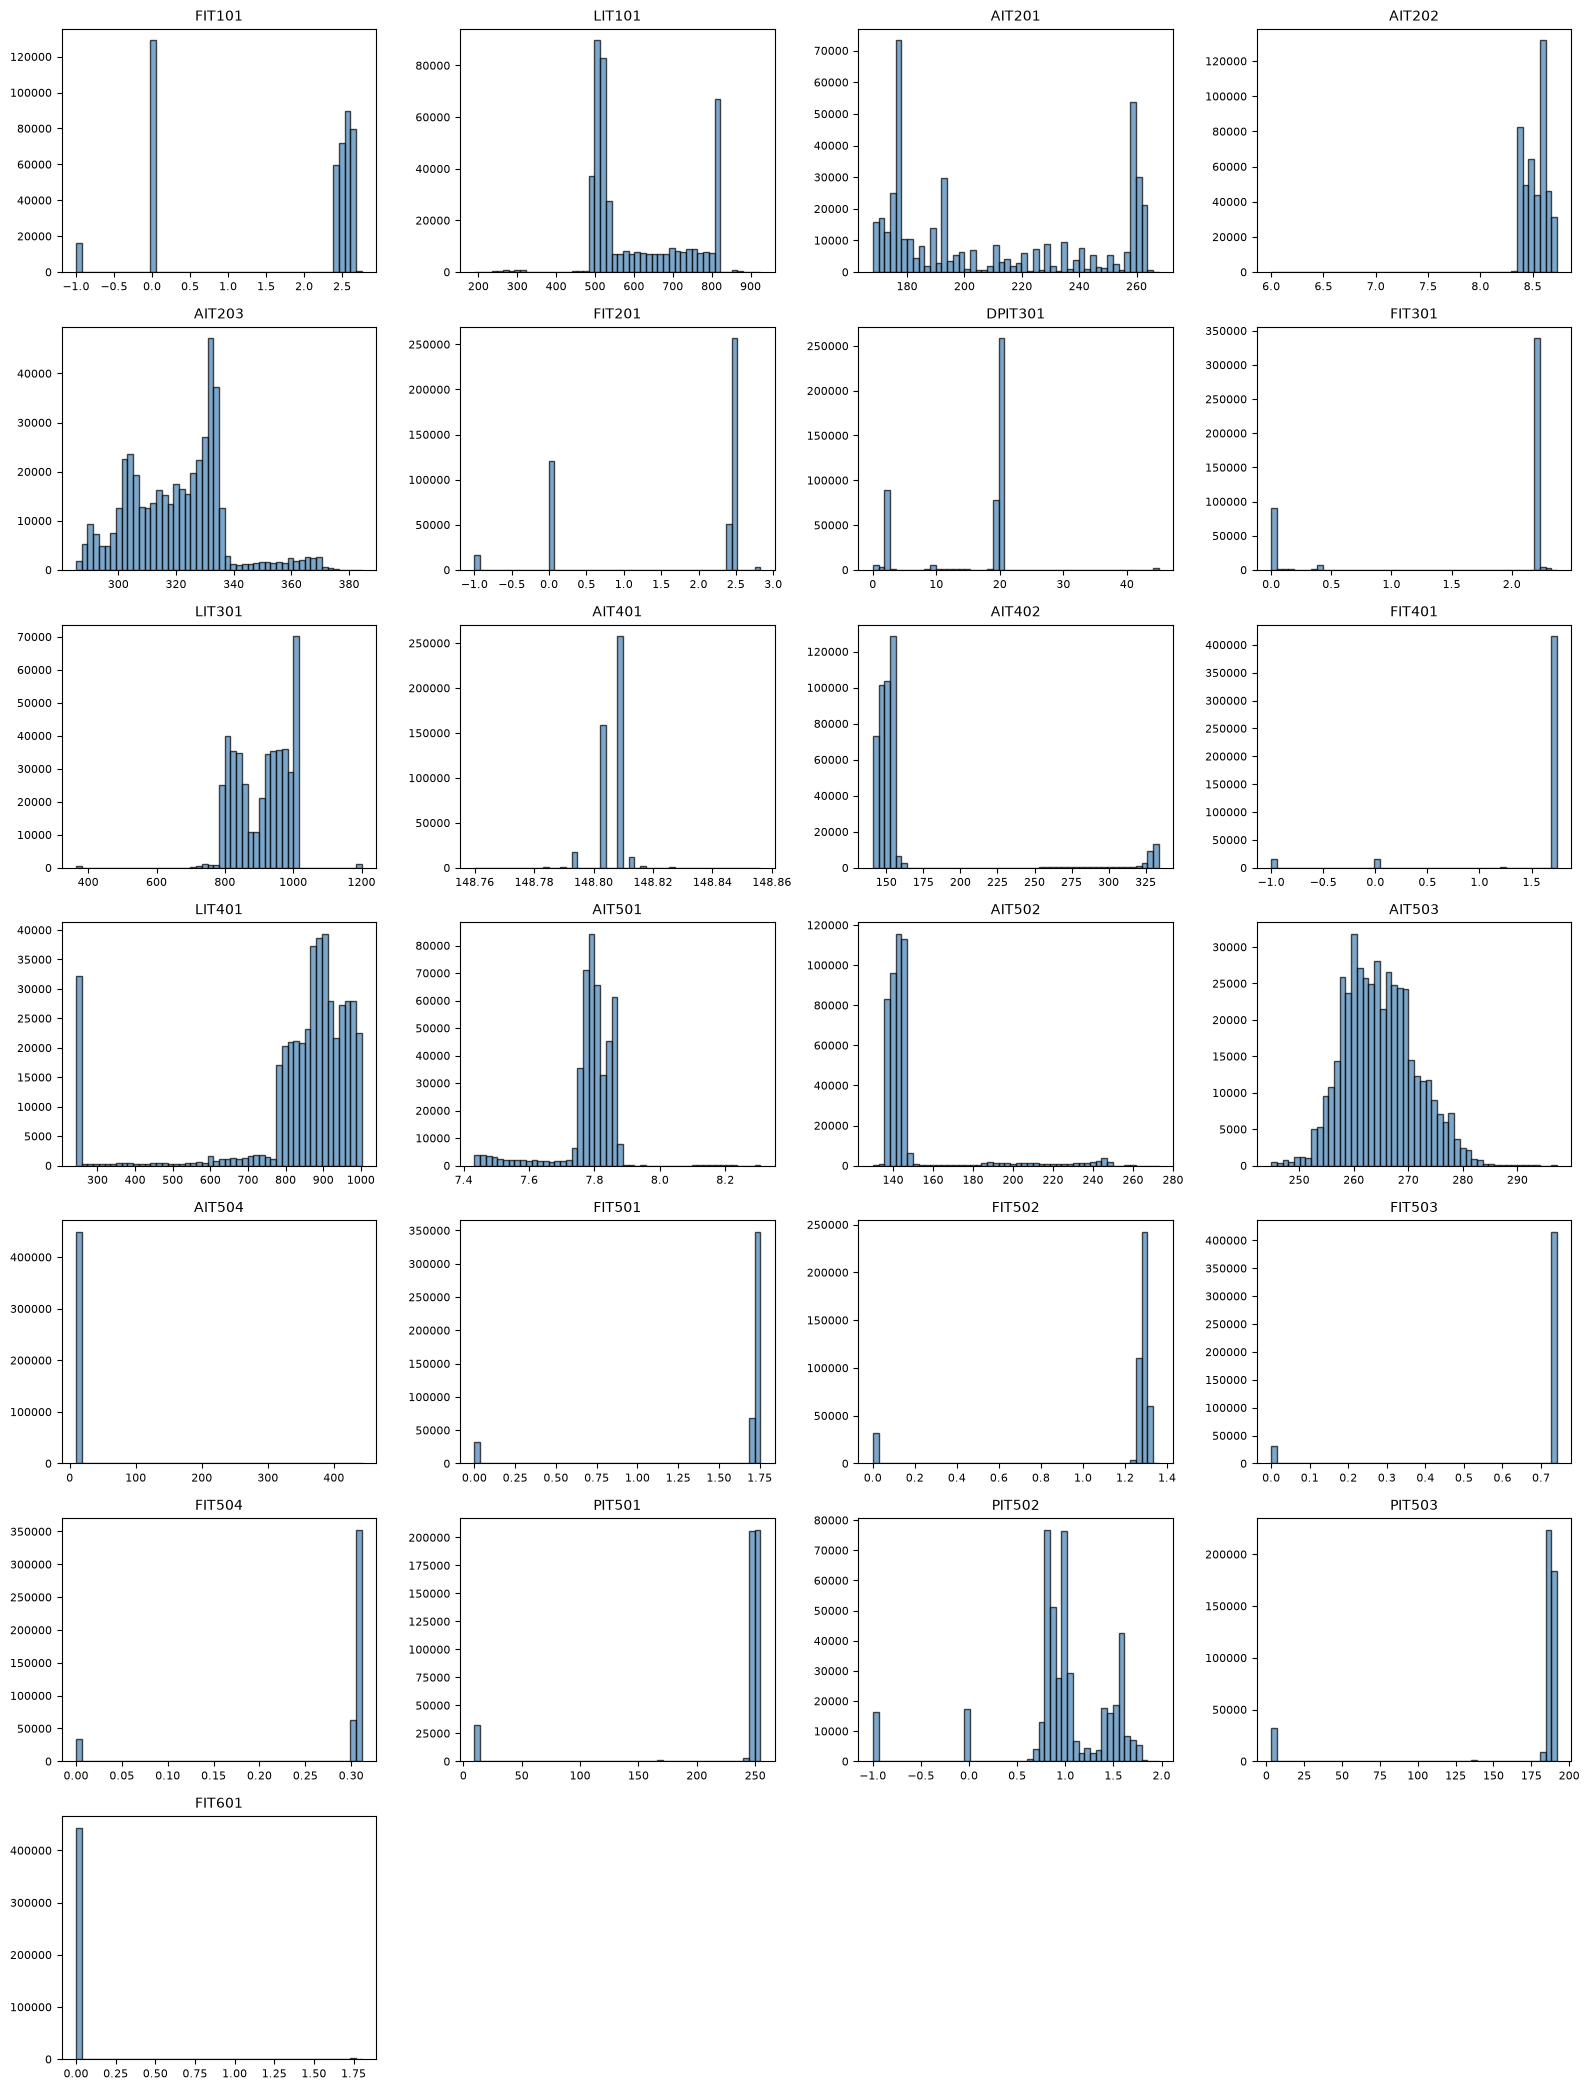

In [25]:
float_cols = df.select_dtypes(include='float64').columns.tolist()

for col in ['Timestamp', 'target']:
    if col in float_cols:
        float_cols.remove(col)

n_cols = 4
n_rows = math.ceil(len(float_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes = axes.flatten()

for i, col in enumerate(float_cols):
    ax = axes[i]
    ax.hist(df[col], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(col, fontsize=10)
    ax.tick_params(labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

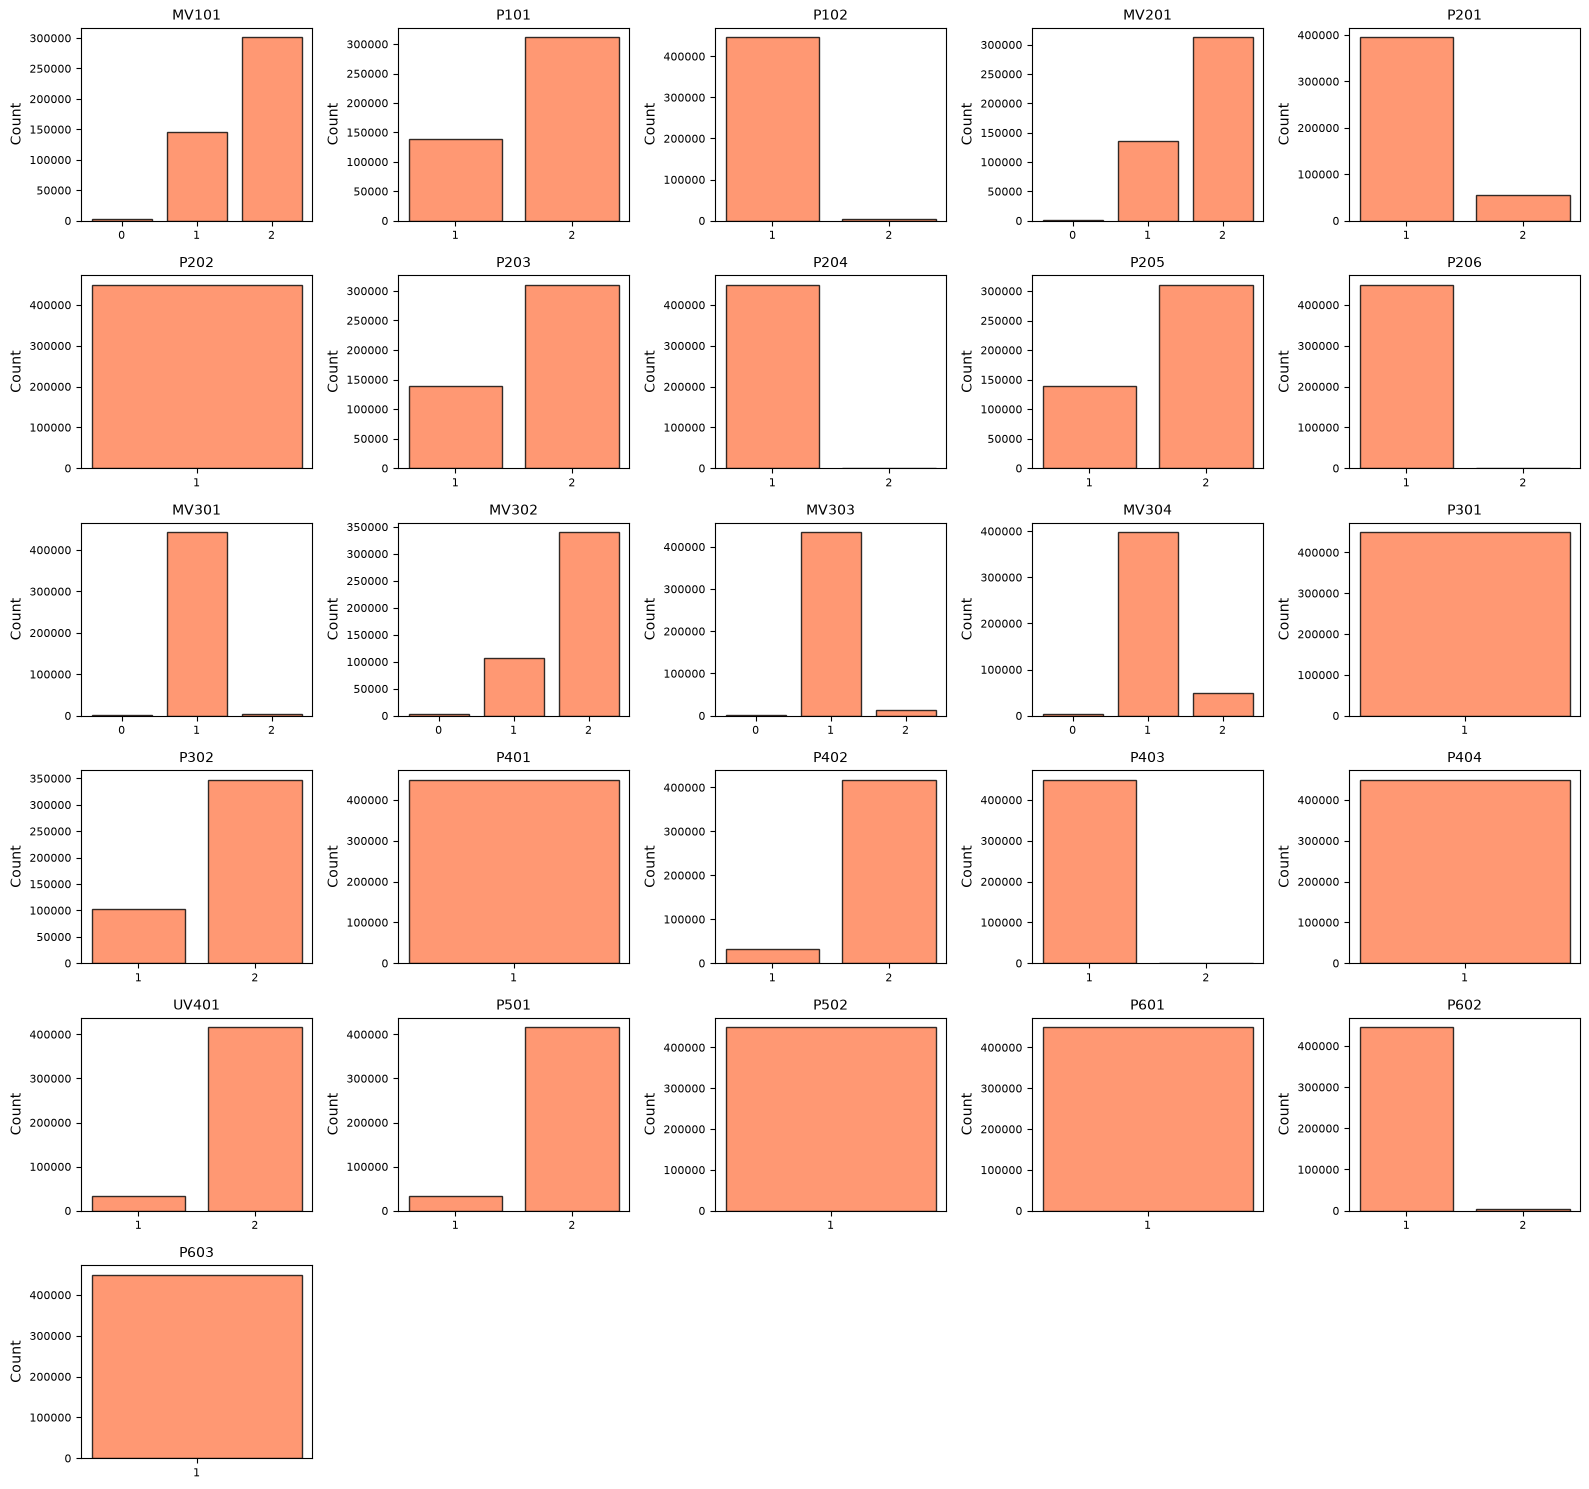

In [26]:
int_cols = df.select_dtypes(include='int64').columns.tolist()
for col in ['target', '']:        
    if col in int_cols:
        int_cols.remove(col)

n_cols = 5
n_rows = math.ceil(len(int_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 2.5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(int_cols):
    ax = axes[i]
    vc = df[col].value_counts().sort_index()
    ax.bar(vc.index.astype(str), vc.values, color='coral', edgecolor='black', alpha=0.8)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('Count')
    ax.tick_params(labelsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Можно дропнуть стролбцы P202, P301, P401, P404, P502, P601 и P603 - Потому что для решения данной задачи эти столбцы не несут информации (опять же врядли в реальной работе можно было бы поступить тк же).

In [27]:
df.drop(['P202', 'P301', 'P401', 'P404', 'P502', 'P601', 'P603'], axis=1, inplace=True) 

C:\Users\serge\AppData\Local\Temp\ipykernel_15508\1120248319.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=df, ax=ax, palette='Set2')
C:\Users\serge\AppData\Local\Temp\ipykernel_15508\1120248319.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Normal', 'Attack'])
C:\Users\serge\AppData\Local\Temp\ipykernel_15508\1120248319.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=df, ax=ax, palette='Set2')
C:\Users\serge\AppData\Local\Temp\ipykernel_15508\1120248319.py:17: UserWarning: set_ticklabe

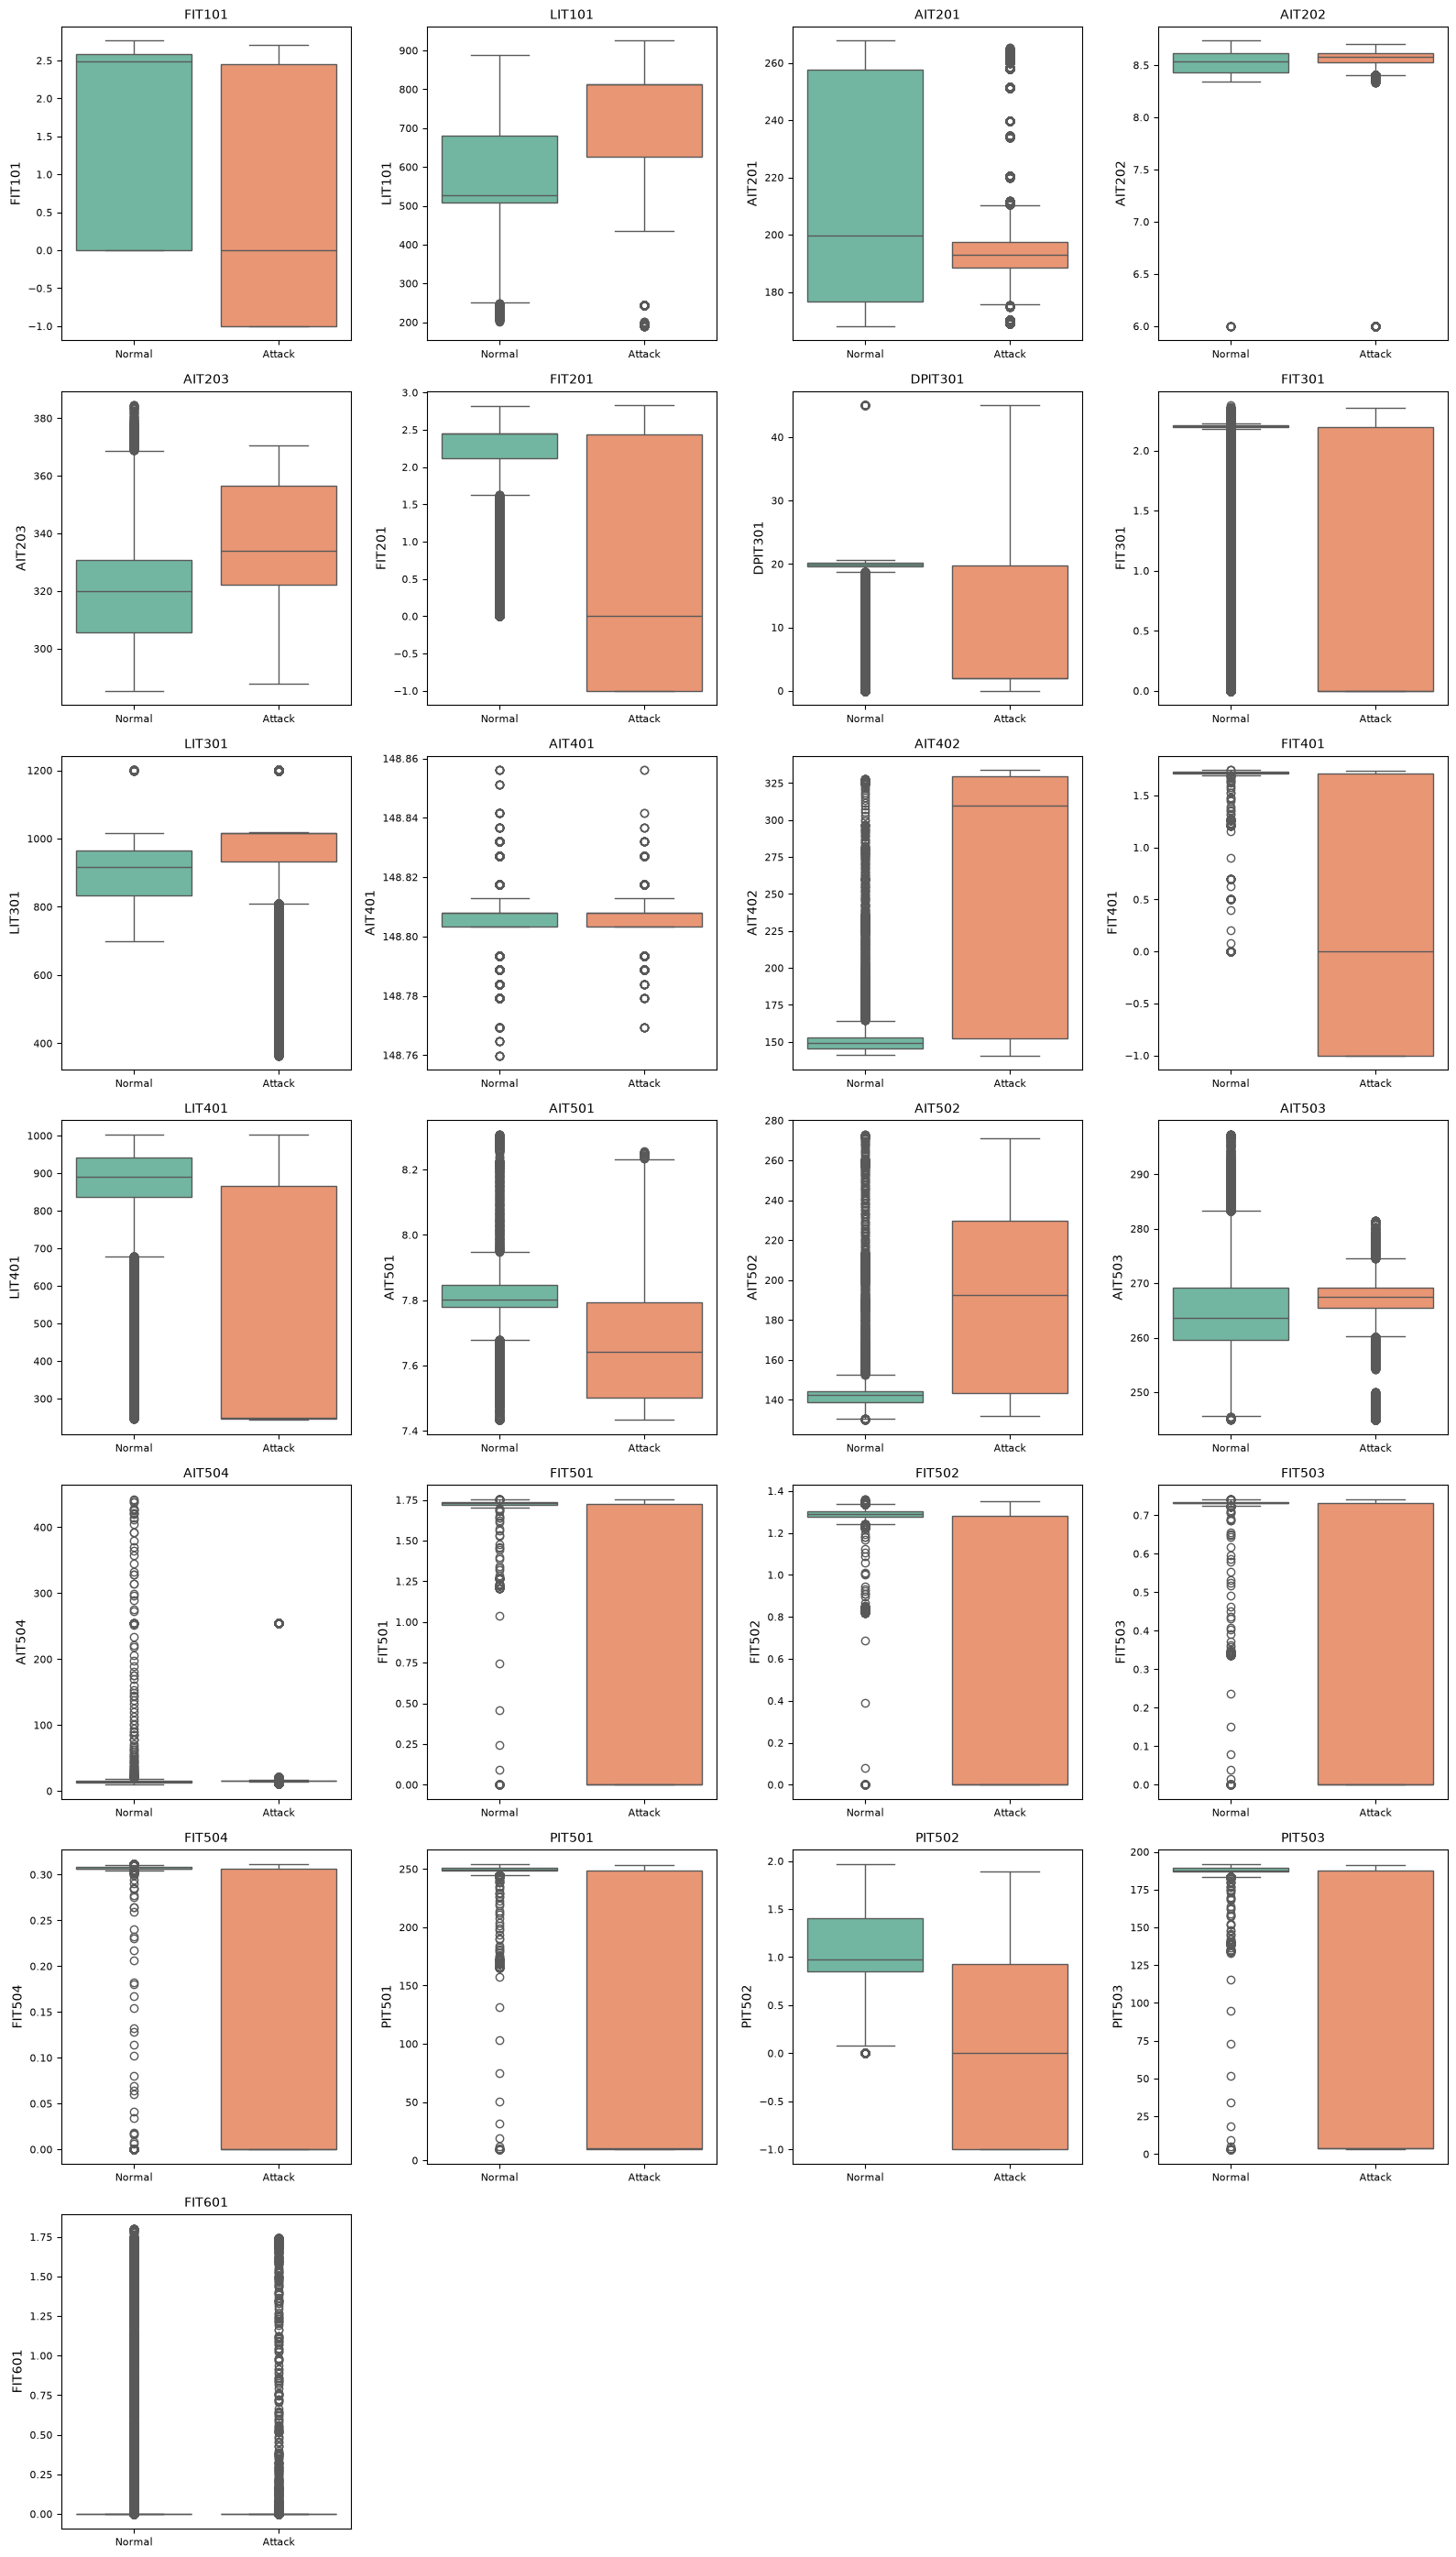

In [28]:
float_cols = df.select_dtypes(include='float64').columns.tolist()

for col in ['Timestamp', 'target']:
    if col in float_cols:
        float_cols.remove(col)

n_cols = 4
n_rows = math.ceil(len(float_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(float_cols):
    ax = axes[i]
    sns.boxplot(x='target', y=col, data=df, ax=ax, palette='Set2')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
    ax.set_xticklabels(['Normal', 'Attack'])
    ax.tick_params(labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Видно, что много признаков несет достатоно информации об атаке для модели (таргет зависит от данных). Чаще всего атака занижает значения поля.

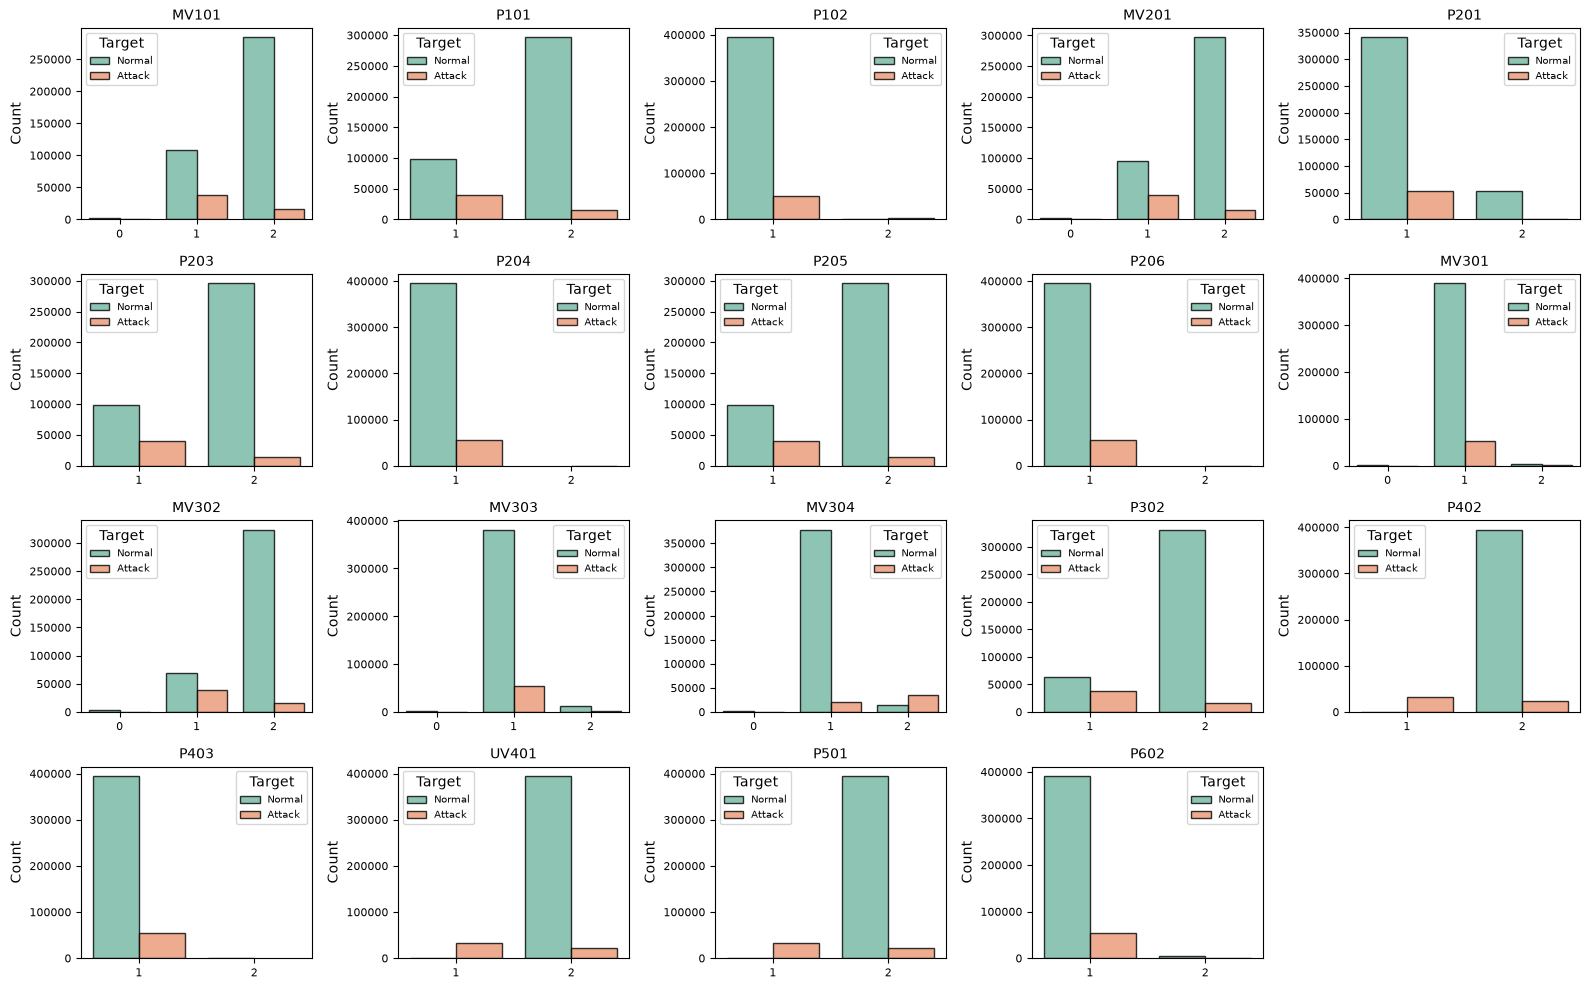

In [29]:
int_cols = df.select_dtypes(include='int64').columns.tolist()

for col in ['target', 'Label']:
    if col in int_cols:
        int_cols.remove(col)

n_cols = 5
n_rows = math.ceil(len(int_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 2.5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(int_cols):
    ax = axes[i]
    sns.countplot(x=col, hue='target', data=df, ax=ax,
                  palette='Set2', edgecolor='black', alpha=0.8)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.legend(title='Target', labels=['Normal', 'Attack'], fontsize=7)
    ax.tick_params(labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Дискретные признаки не несут такой явной информации для модели, но и бесполезных признаков среди них больше не осталось

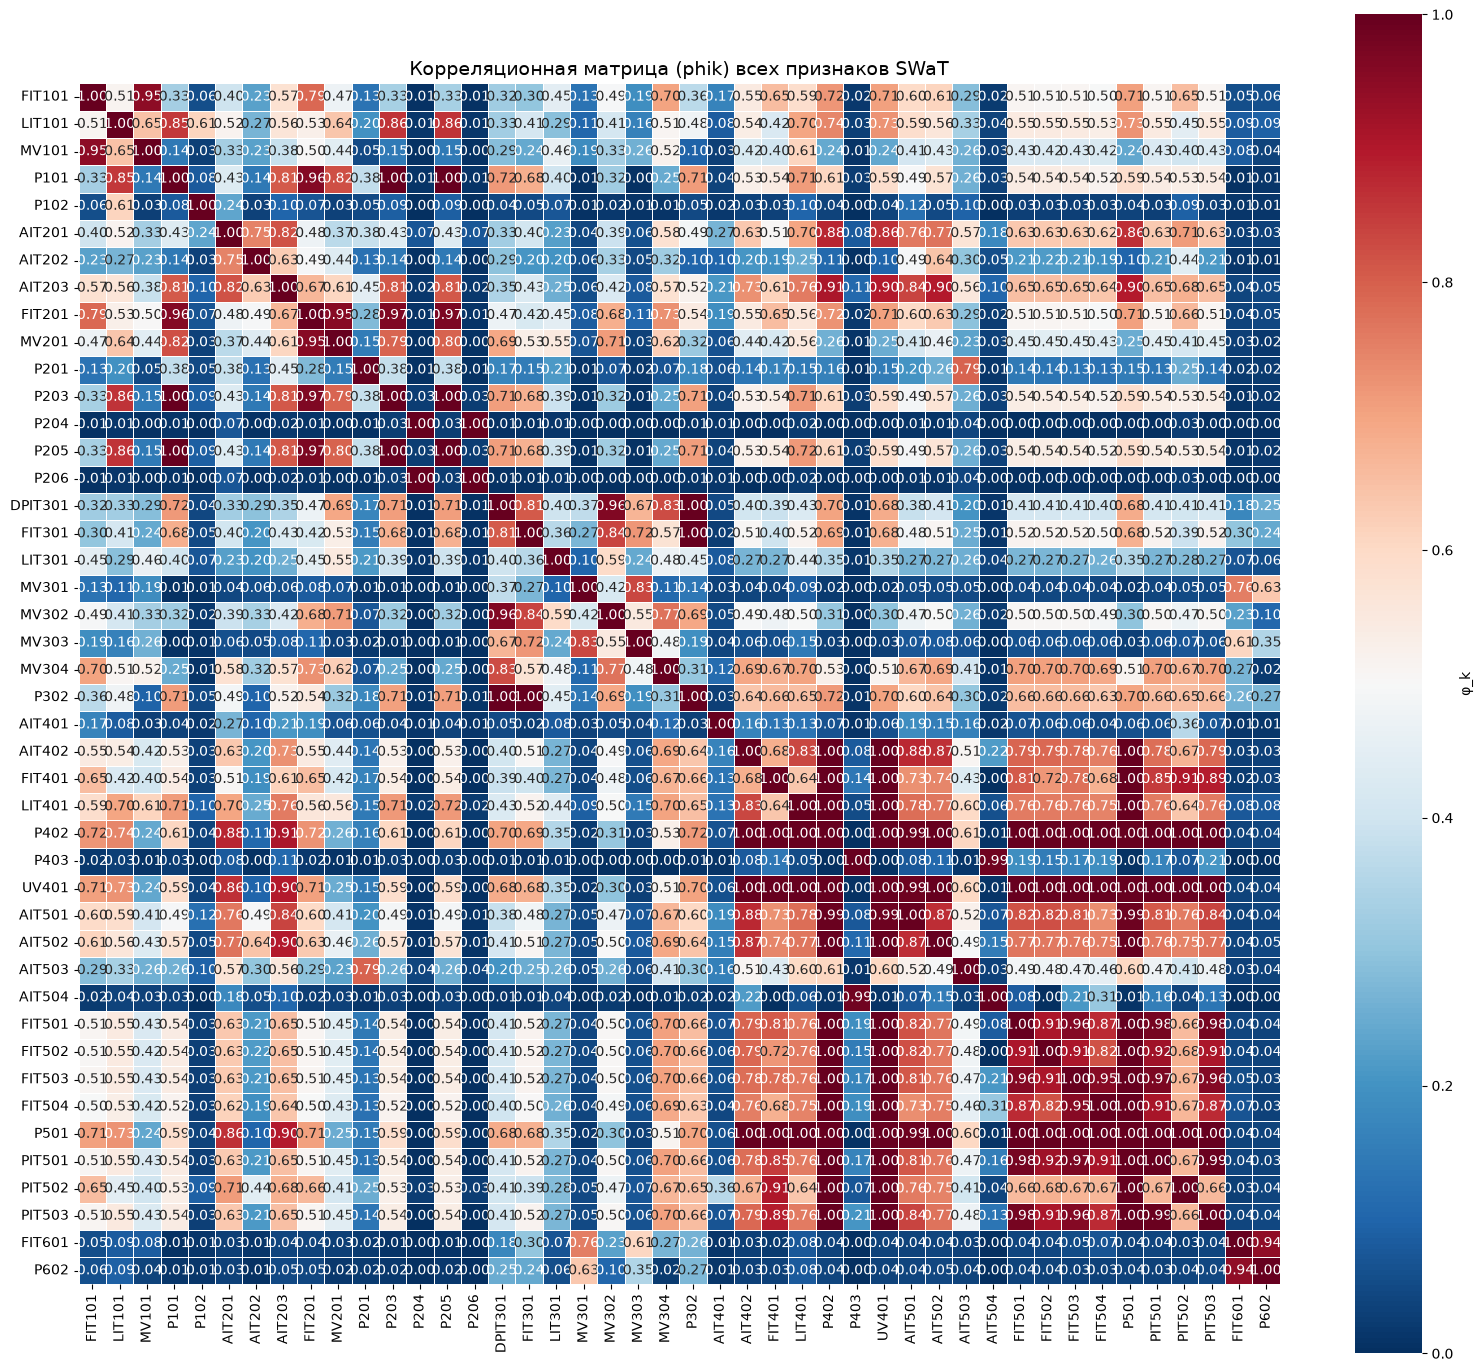

In [30]:
exclude_cols = ['Timestamp', 'target']
features = [col for col in df.columns if col not in exclude_cols]

phik_matrix = df[features].phik_matrix(interval_cols=float_cols)

plt.figure(figsize=(16, 14))
sns.heatmap(phik_matrix, annot=True, fmt='.2f', cmap='RdBu_r', vmin=0, vmax=1,
            linewidths=0.5, square=True, cbar_kws={'label': 'φ_k'})
plt.title('Корреляционная матрица (phik) всех признаков SWaT', fontsize=14)
plt.tight_layout()
plt.show()

Признаки P402, UV401 и P501 сильно скоррелированы со множествм других, поэтому стоит их удалить. Как идея их можно попробовать объеденить при помощи PCE. Но для базового решения просто удалим самые скореллированные признки и не будем использовать линейные модели.

In [31]:
df.drop(['P402', 'UV401', 'P501'], axis=1, inplace=True)

# Подготовка к моделированию

In [32]:
df = df.sort_values('Timestamp').reset_index(drop=True)

In [33]:
warnings.filterwarnings('ignore')

sensor_cols = [col for col in df.columns 
               if col not in ['Timestamp', 'target']]

train_size = int(len(df) * 0.8)
train = df.iloc[:train_size]
test  = df.iloc[train_size:]

print(f'Train: {train.shape[0]}, Test: {test.shape[0]}')

X_train = train[sensor_cols]   
y_train = train['target']

X_test = test[sensor_cols]
y_test  = test['target']

print(f'Размерности: X_train {X_train.shape}, X_test {X_test.shape}')
print(f'Признаков всего: {X_train.shape[1]}')
print(f'Train attack: {y_train.mean()*100:.2f}%')
print(f'Test attack: {y_test.mean()*100:.2f}%')

Train: 359935, Test: 89984
Размерности: X_train (359935, 41), X_test (89984, 41)
Признаков всего: 41
Train attack: 13.87%
Test attack: 5.23%


# LightGBM

In [36]:
neg, pos = np.bincount(y_train.astype(int))
model = lgb.LGBMClassifier(
    objective='binary',          
    metric='average_precision',  
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    is_unbalance=True,           
    random_state=42,
    verbose=-1
)

model.fit(X_train, y_train)

,max_depth,6
,learning_rate,0.05
,n_estimators,500
,objective,'binary'
,random_state,42
,metric,'average_precision'
,is_unbalance,True
,verbose,-1
,boosting_type,'gbdt'
,num_leaves,31
,subsample_for_bin,200000


              precision    recall  f1-score   support

      Normal       0.95      1.00      0.97     85280
      Attack       0.00      0.00      0.00      4704

    accuracy                           0.95     89984
   macro avg       0.47      0.50      0.49     89984
weighted avg       0.90      0.95      0.92     89984

ROC-AUC: 0.5399
F1 (Attack): 0.0000
Precision: 0.0000
Recall: 0.0000


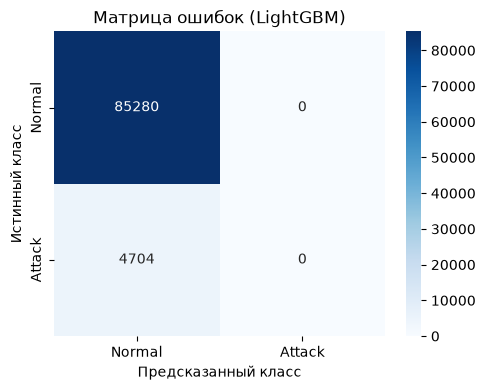

In [37]:
y_pred_proba = model.predict_proba(X_test)[:, 1]  
y_pred = (y_pred_proba > 0.5).astype(int)          

print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))

print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"F1 (Attack): {f1_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.title('Матрица ошибок (LightGBM)')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

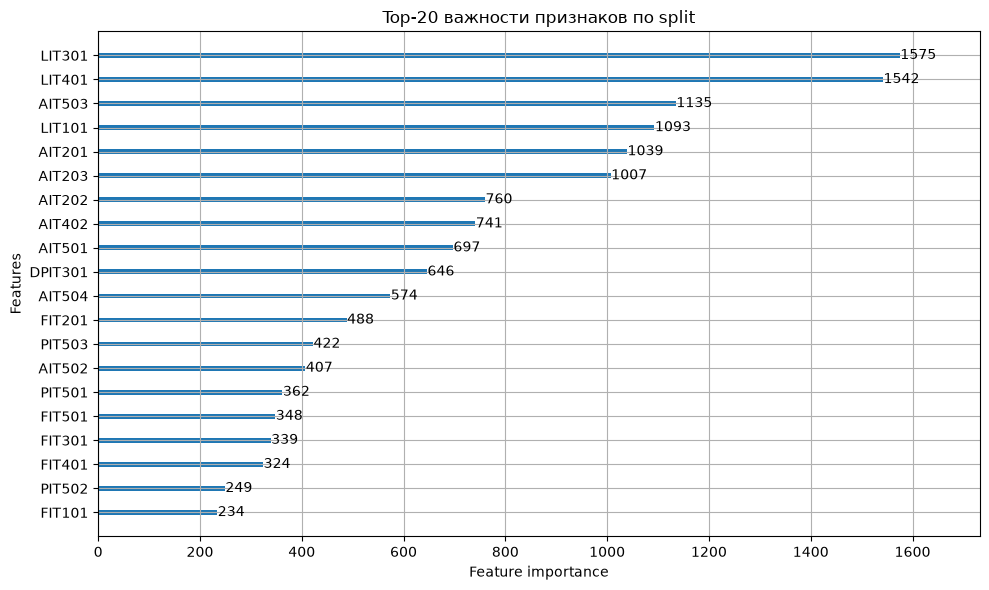

In [38]:
lgb.plot_importance(model, max_num_features=20, figsize=(10,6), importance_type='split')
plt.title('Top-20 важности признаков по split')
plt.tight_layout()
plt.show()

Подбор трешхолда для максимизации F1

In [39]:
prec, rec, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1_scores = 2 * prec * rec / (prec + rec + 1e-10)
best_thr = thresholds[np.argmax(f1_scores)]
y_pred_adj = (y_pred_proba >= best_thr).astype(int)

In [40]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-12)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Оптимальный порог по F1: {best_threshold:.4f}")
print(f"F1 на атаках: {f1_scores[best_idx]:.4f}")
print(f"Precision: {precisions[best_idx]:.4f}")
print(f"Recall: {recalls[best_idx]:.4f}")

y_pred_best = (y_pred_proba >= best_threshold).astype(int)

print(classification_report(y_test, y_pred_best, target_names=['Normal', 'Attack']))

Оптимальный порог по F1: 0.0006
F1 на атаках: 0.1570
Precision: 0.2694
Recall: 0.1108
              precision    recall  f1-score   support

      Normal       0.95      0.98      0.97     85280
      Attack       0.27      0.11      0.16      4704

    accuracy                           0.94     89984
   macro avg       0.61      0.55      0.56     89984
weighted avg       0.92      0.94      0.93     89984



# Isolation Forest

In [41]:
X_train_normal = X_train[y_train == 0]

iso_forest = IsolationForest(
    n_estimators=200,
    max_samples='auto',
    contamination=0.0001,     
    random_state=42,
    n_jobs=-1
)


iso_forest.fit(X_train_normal)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.0001
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [42]:
y_pred_raw = iso_forest.predict(X_test) 
y_pred = np.where(y_pred_raw == -1, 1, 0)       
anomaly_score = iso_forest.score_samples(X_test) 
anomaly_score_inv = -anomaly_score

              precision    recall  f1-score   support

      Normal       0.95      1.00      0.97     85280
      Attack       0.00      0.00      0.00      4704

    accuracy                           0.95     89984
   macro avg       0.47      0.50      0.49     89984
weighted avg       0.90      0.95      0.92     89984

ROC-AUC (по anomaly score): 0.5951


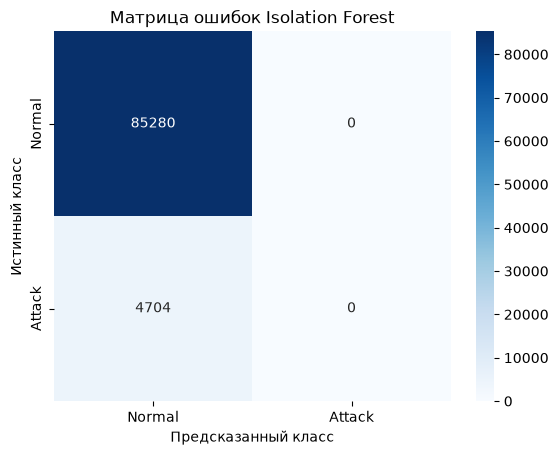

In [43]:
print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))

roc_auc = roc_auc_score(y_test, anomaly_score_inv)
print(f"ROC-AUC (по anomaly score): {roc_auc:.4f}")

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.title('Матрица ошибок Isolation Forest')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.show()

In [44]:
precisions, recalls, thresholds = precision_recall_curve(y_test, anomaly_score_inv)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-12)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Оптимальный порог (по anomaly score): {best_threshold:.4f}")
print(f"F1: {f1_scores[best_idx]:.4f}")
print(f"Precision: {precisions[best_idx]:.4f}")
print(f"Recall: {recalls[best_idx]:.4f}")

y_pred_opt = (anomaly_score_inv >= best_threshold).astype(int)

print("\n=== Отчёт с оптимальным порогом ===")
print(classification_report(y_test, y_pred_opt, target_names=['Normal', 'Attack']))

Оптимальный порог (по anomaly score): 0.5832
F1: 0.1808
Precision: 0.1936
Recall: 0.1696

=== Отчёт с оптимальным порогом ===
              precision    recall  f1-score   support

      Normal       0.95      0.96      0.96     85280
      Attack       0.19      0.17      0.18      4704

    accuracy                           0.92     89984
   macro avg       0.57      0.57      0.57     89984
weighted avg       0.91      0.92      0.92     89984

